In [ ]:
Content
1. Inference Time Technique
2. Model Training
3. Training Techniques
4. Fine Tuneing with Closed Source LLM models

# 1. Inference Time Technique

In [ ]:
# Inference Time Technique to get better answers
1. Multi-shot prompting
2. Tools/ Functions Calling
3. RAG/ Knowledge Base

# 2. Model Training

In [ ]:
- Model Training: It involves the parameters of a model based on input and output
- Generalization: The ability of a model to make good predictions on unseen data is called "Generalization" and LLMs are very good at this.
- Model Training requires million of dollar.
- We will use Transfer Learning: We take a pre-trained model as base, and use additional training data to fine-tune it.

### 2.1 Steps for Training

In [ ]:
Training: Tweaking the parameters of a model based on training data, in a way that it should generalize to unseen data.

# Steps:
1. Forward Pass: Predict the output, given inputs
2. Loss Calculation: How different was the prediction to the ground truth.
3. Backward Pass: How should we tweak parameters to do better next time. (the gradients)
4. Update parameters a tiny step to do better next time.



In [ ]:
# Key Terms:
1. Hyper-parameters: You can specify additional settings that are not updated during training known as hyper-parameters.
2. Epoch: No. of iterations for learning.
3. Learning Rate: Rate of change of parameters, so it perform better next time.
4. Quantization (Not a Training Technique):
    - Reduces the precision per parameter, but does nto reduce the number of parameters
    - Example:    
        - Llama 3.2-3B with Quantized to 8 bit = 3.6 GB. Althought the original model size is 13 GB
        - Instead of Storing each weight as 32 bit float, we store as 8-bit float => 8/8 => 1 byte
        - 3B * 1 byte => 3 GB + 600 MB of metadata, => 3.6



# 3. Training Techniques

In [ ]:

    
2. LoRA (Low Rank Adaptation)
    - Fine-tuning a large LLM with Billion of parameters is expensive, as it performs Full backprop through entire model.
    - So, LoRA (Low-Rank Adaptation) lets you fine-tune without changing most parameters.

    - Idea: Freeze the original model weights and learn only a small low-rank update matrix, So Instead of learning a millions of parameters, learn just a few thousands
    - Steps:
        Step 1: First, we first select a few layers, called Target Modules.
        Step 2: we create a seperate matrix/ parameters which are of a few dimensions, called Low Rank Adaptor.
        Step 3: We train the Low Rank Adaptor parameters.
        Step 4: We just add the Low Rank Adapter matrix to the selected Target Modules.
    - But there is a problem with matrix dimensions.
        - There are two matrix for each Target Module (LoRA_a, LoRA_b)

    - Maths
        - In Transformers, learnable power is inside linear layers:
            -   Q, K, V projections
                Output projection
                FFN layers
        - W_new = W_frozen + ΔW
            - ΔW = A × B
              A ∈ R(d × r)
              B ∈ R(r × k)
        - Original Layer
            - y = W x
            - 4096 × 4096 = 16,777,216 params
        - LoRA Layer
            - y = W x + (A B) x
                * W is a matrix with d rows, k columns, x is input vector, y is output vector, W is trainable weights, r is much smaller number of LoRA
            -   A: 4096 × 8  = 32,768 (LoRA with rank matrix as 8)
                B: 8 × 4096  = 32,768
                ---------------------
                Total ≈ 65,536 params

# If we don't use the LoRA
    - We have to run forwards, backword pass, loss calculation, and then update on full model.


# Hyper parameters for LoRA
1. Rank: How many dimensions in the low-rank matrices.
    - Rule: Start with 8, then double to 16, 32, untill diminishing returns
2. Alpha: A scaling factor that multiplies the lower rank matrices
    - Rule: Twice the value of r
3. Target Modules: Which layers of the neural network are adapted.
    - Rule: Start by trageting the attention heads 



In [ ]:
# Linear Layers Calculation for LoRA with Llama 3.2B-3B

# LoRA is applied on Selective Layers
- Llama 3.2-3B, has 26-32 blocks (depends on variant) => ~30 blocks
- Each layer has around ~6 linear layer => Total linear layers => 30 * 6 => 180 layers

# Which layers of LLM usually apply LoRA
- LoRA is NOT applied to every linear layer.
- Setup 1 (very common), LoRA is applied to following 2 layers only
    - ✔ Wq (Query)
    - ✔ Wv (Value)

    - In this Setup, 30 blocks * 2 => 60 linear layers

- Setup 2, LoRA is applied to following 4 layers only
    - ✔ Wq (Query)
    - ✔ Wv (Value)
    - ✔ Wo
    - ✔ FFN projections    

    - In this Setup, 30 blocks * 4 => 120 linear layers

Transformer Block #1
 ├─ Wq  ← LoRA here
 ├─ Wk
 ├─ Wv  ← LoRA here
 ├─ Wo
 ├─ FFN W1
 ├─ FFN W2

Transformer Block #2
 ├─ Wq  ← LoRA here
 ├─ Wk
 ├─ Wv  ← LoRA here
 ...


# Why LoRA is applied selectively
- Attention Q,V control behavior most
- FFN stores general knowledge
- Fewer LoRA layers = smaller adapter
- Pros: Low memeory, Training stable, Performance high
    
    

In [ ]:
# Linear Layers additional Weight Calculation for LoRA with Llama 3.2B-3B

# LoRA formula
    ΔW = A × B
    A ∈ R(d × r)
    B ∈ R(r × k)

    r = 32 (very small)
    d = k = 4096

- In a 3B transformer (example)
    - In 30 transformer blocks * 2 linear layers (where LoRA ~100–120 linear layers adapted on which LoRA/ QLoRA will be applicable.
    - Typical hidden size ≈ 4096

- Per Layer LoRA parameters
    A: 4096 × 32 = 131,072
    B: 32 × 4096 = 131,072
    Total ≈ 262K params per layer

- For 120 linear layers, where LoRA will be applicable
    - 262K params per layer × 120 layers ≈ 31 million params

# Storage for LoRA Weights
    - LoRA usually store weigts in FP16, FP16 => 16 bits/ 8 => 2 bytes per parameter
    - 31M parameters * 2 bytes => 62 MB + some metadata => 73 MB

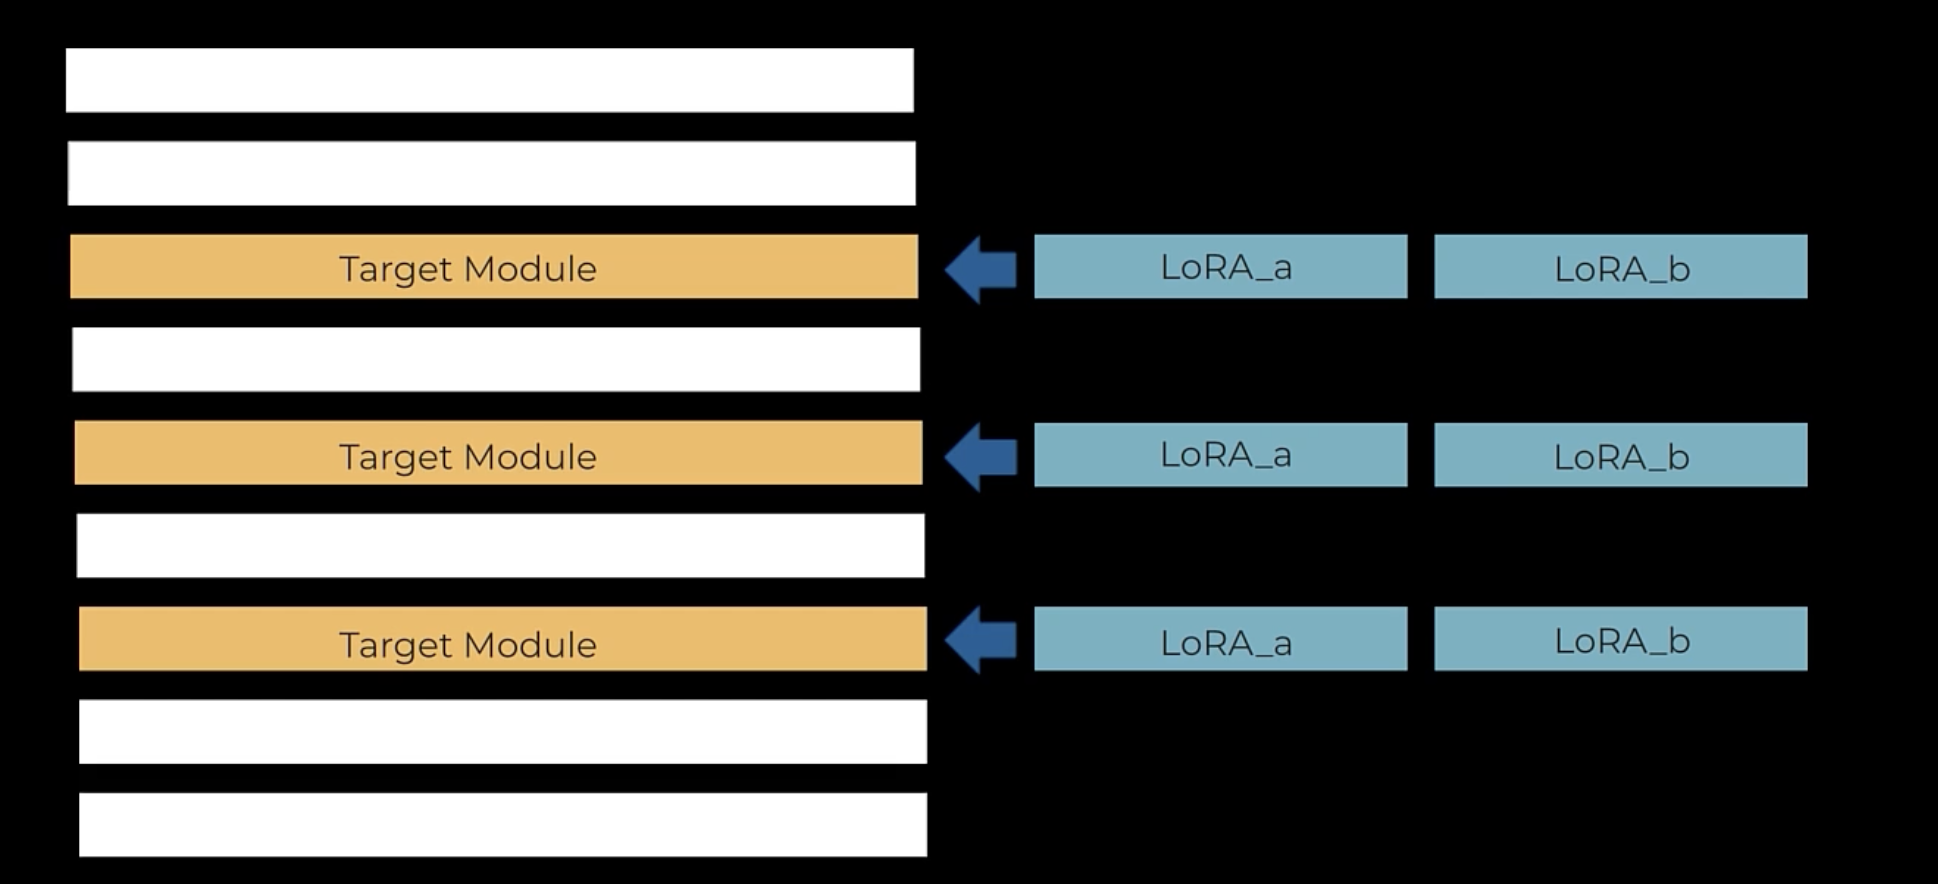

In [ ]:
3. QLoRA (Quantization Low Rank Adaptation)
    - QLoRA = Quantization + LoRA
    - Intuition: Keep the number of weights same, but reduce their precision.
    - Model performance is worse, but the impact is surprisingly small.
    - Reduce to 8 bits, or even to 4 bits. 
        - These 4 bits are interpreted as float, not int.
        - Here, quantization is done on the base model, converting to lower bits.

In [ ]:
# Reduction in Size for Llama Weights in MB
1. Llama 3.2-3B = 13 GB
    - 1 parameter = 32 bit float (default) = 32/8 = 4 bytes
    - 13B * 4 bytes => 12 GB + 1 GB Meta Data => 13 GB

2. Llama 3.2-3B with Quantized to 8 bit = 3.6 GB
    - Instead of Storing each weight as 32 bit float, we store as 8-bit float => 8/8 => 1 byte
    - 3B * 1 byte => 3 GB + 600 MB of metadata

3. Llama 3.2-3B with Quantized to 4 bit = 2.2 GB
    - Still all 3B weights are present, just very compressed.
    - 3B * 0.5 byte => 1.5 GB + 700 MB of metadata => 2.2 GB

4. Llama 3.2-3B with QLoRA with r=32 = 73 MB
    - QLoRA = Quantization + LoRA
    - Part 1: Quantization
        - The entire 3B model is Quantized to 4-bit and all weights are frozen (not trainable) => 2.2 GB
        - But this is NOT what you save or upload
    - Part 2: LoRA
        - With QLoRA, you only save the Low-Rank Adapter weights (LoRA) => 73 MB


# Size Comparison
1. Llama 3.2-3B Base model
    - 3,000,000,000 parameters
    - Size: 13 GB GB

2. Llama 3.2-3B Base model (frozen, and Quantized with 8 bit)
    - 3,000,000,000 parameters
    - Size: 3.6 GB

3. LoRA adapter (saved explicitly):
    - 31,000,000 parameters (trainable)
    - 73 MB

# 4. Fine Tuneing with Closed Source LLM models

### 1. Fine-Tuning with Open AI

In [ ]:
# Fine-Tuning
# Page: 

Traning generates a small model with the customized weights, which is private only for the user. Only a small number of parameters are updated.

- LORA: To change a small number of parameters, that affects the bigger model. 

# Type of Training on OpenAI
1. Supervised fine-tuning
    - https://platform.openai.com/docs/guides/supervised-fine-tuning
    - It lets you train an OpenAI model with examples for your specific use case. The result is a customized model that more reliably produces your desired style and content.
    - Best for:
        - Classification
        - Nuanced translation
        - Generating content in a specific format
        - Correcting instruction-following failures

2. Direct preference optimization
    - Provide both a correct and incorrect example response for a prompt. Indicate the correct response to help the model perform better.
    - Best for:
        - Summarizing text, focusing on the right things
        - Generating chat messages with the right tone and style

            
3. Reinforcement fine-tuning
    - When we don't have correct/ expected results, instead we may add a judge to grade the results, and reinfornce the model's chain of though for higher scored responses.
            
            
# Fine turning is very similar to batch mode.

# Steps
1. Create Training dataset in Jsonl format (each line is a json format) and upload to Open AI
2. Run training - training loss and validation loss should decrease
3. Evaluate results, tweak and repeat

In [ ]:
# Data Points in fine turning
- Open AI recomends fine-tuning with a small population of 50-100 examples only.
  Because we are working on a heavyly trained model, as it has already been trained.

Key Objectives of Fine-Tuning for Frontier models
    1. Setting style or tone in a way that can't be achieved with prompting
    2. Improving the reliability of producing a type of output
    3. Correcting failures to follow complex prompts
    4. Handling edge cases
    5. Performing a new skill or task that's hard to articulate in a prompt    